# [LAB 13] 3. 통계적 시계열 분석의 접근 - ACF / PACF

In [ ]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np

# ADF 테스트 - 정상성 확인용
from statsmodels.tsa.stattools import adfuller

# ACF, PACF 테스트
from statsmodels.tsa.stattools import acf, pacf

# ACF, PACF 시각화 기능
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ADF 테스트 - 정상성 확인용
from statsmodels.tsa.arima.model import ARIMA

In [3]:
origin = load_data("air_passengers")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/air_passengers.xlsx
[desc] 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (144, 2)
열 개수: 2
행 개수: 144

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB
None


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


,차수,ADF Statistic,p-value,result
0,0,0.815369,9.918802e-01,False
1,1,-2.829267,5.421329e-02,False
2,2,-16.384232,2.732892e-29,True


,Month,Passengers
2,-3 days,8.0
3,3 days,-17.0
4,-1 days,-5.0
5,1 days,22.0
6,-1 days,-1.0


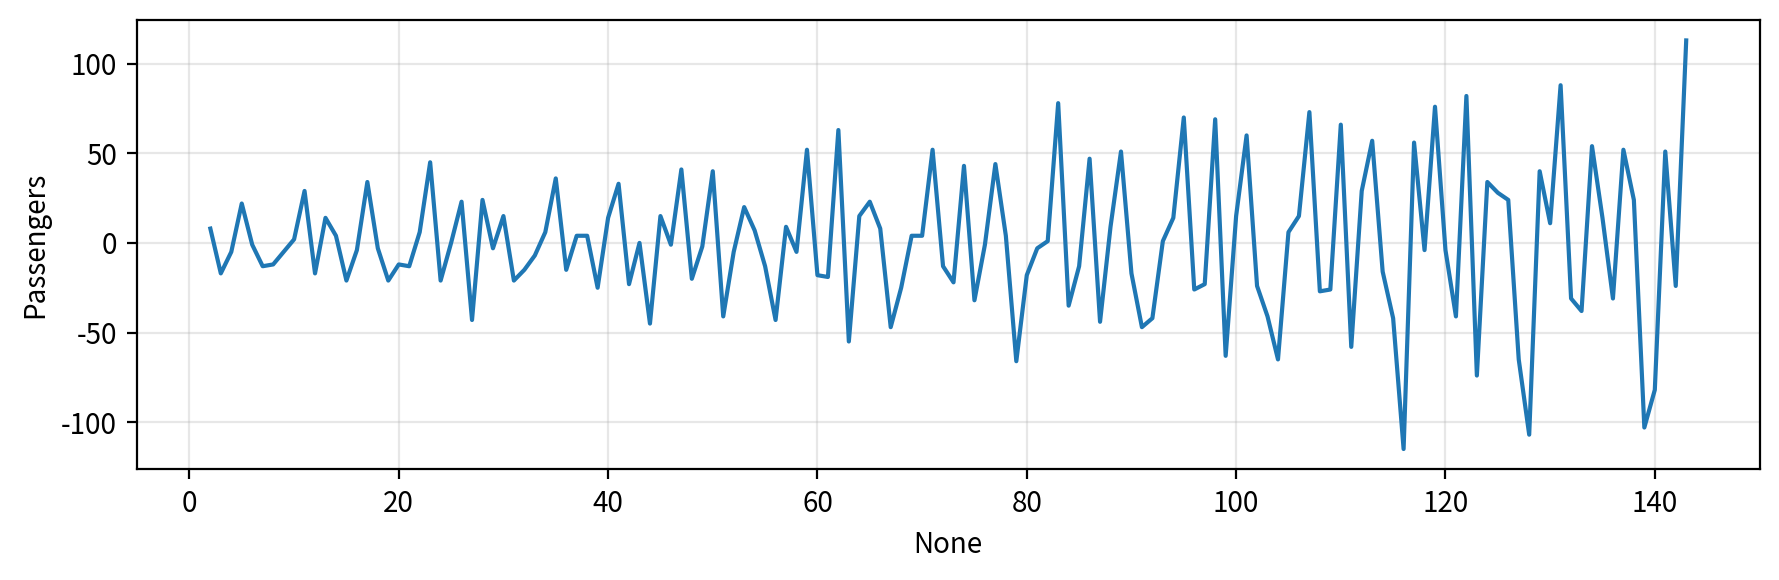

In [5]:
diff_df = origin.copy()
yname = "Passengers"
diff_count = 0
result = []

while True:
    ar = adfuller(diff_df[yname])

    ar_dict = {
        "차수": diff_count,
        "ADF Statistic": ar[0],
        "p-value": ar[1],
        "result": True if ar[1] <= 0.05 else False,
    }

    # 리스트에 정상성 검사 결과 저장
    result.append(ar_dict)

    # 정상성 충족이면 반복 중단
    if ar_dict["result"]:
        break

    # 정상성이 충족되지 않았다면 차분 수행 후 다시 수행
    diff_count += 1
    diff_df = diff_df.diff().dropna()

# 차분 결과표
display(DataFrame(result))

# 차분의 결과로 생성된 데이터프레임
display(diff_df.head())

# 차분 결과 시각화
width_px = 1800
height_px = 600
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)

fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.lineplot(data=diff_df, x=diff_df.index, y=yname, ax=ax)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

In [6]:
# 1) 차분된 시계열의 자기상관계수(ACF) 계산 (lag 0부터 시작)
acf_vals = acf(diff_df["Passengers"], fft=False)

# 2) ACF 유의성 판단 기준 (근사적 95% 신뢰구간)
threshold = 2 / np.sqrt(len(diff_df["Passengers"]))

# 3) 임계값을 초과하는(유의한) lag 인덱스 추출
significant_lags = np.where(np.abs(acf_vals) > threshold)[0]

# 4) 결과 확인
acf_vals, threshold, significant_lags

(array([ 1.        , -0.19100587, -0.19598169, -0.0485473 , -0.20664662,
         0.11939696,  0.02575129,  0.14558204, -0.22613908,  0.01407533,
        -0.2082756 , -0.12089977,  0.78224898, -0.09592873, -0.19547382,
        -0.07034343, -0.14794844,  0.11319557,  0.01921939,  0.13695131,
        -0.24015233,  0.02613065]),
 np.float64(0.16783627165933782),
 array([ 0,  1,  2,  4,  8, 10, 12, 14, 20]))

In [7]:
# 1) ACF 계산
acf_vals = acf(diff_df["Passengers"])
threshold = 2 / np.sqrt(len(diff_df["Passengers"]))

# 2) 결과표 생성
df_acf = DataFrame(
    {
        "lag": np.arange(len(acf_vals)),
        "acf": acf_vals,
    }
)

# 3) 유의성 판단
df_acf["abs_acf"] = df_acf["acf"].abs()
df_acf["significant"] = df_acf["abs_acf"] > threshold

# 4) 보기 좋게 정리
df_acf["acf"] = df_acf["acf"].round(3)
df_acf["abs_acf"] = df_acf["abs_acf"].round(3)
df_acf["threshold"] = round(threshold, 3)

# 5) lag=0 제외 (판정용)
df_acf_result = df_acf.query("lag > 0").reset_index(drop=True)

# 6) 연속 유의 구간 계산
df_acf_result["prev_significant"] = df_acf_result["significant"].shift(1)

# (A) 유의가 "끝나는" 지점: True -> False
df_acf_result["cut_candidate"] = (df_acf_result["prev_significant"] == True) & (
    df_acf_result["significant"] == False
)

# (B) 유의가 "시작되는" 지점: False -> True  (네가 원래 "/=True" "/=False"로 쓰려던 의도일 수도 있어서 같이 둠)
df_acf_result["start_candidate"] = (df_acf_result["prev_significant"] == False) & (
    df_acf_result["significant"] == True
)

df_acf_result[["lag", "acf", "significant", "cut_candidate", "start_candidate"]]

,lag,acf,significant,cut_candidate,start_candidate
0,1,-0.191,True,False,False
1,2,-0.196,True,False,False
2,3,-0.049,False,True,False
3,4,-0.207,True,False,True
4,5,0.119,False,True,False
5,6,0.026,False,False,False
6,7,0.146,False,False,False
7,8,-0.226,True,False,True
8,9,0.014,False,True,False
9,10,-0.208,True,False,True


In [9]:
q_candidate = df_acf_result.loc[df_acf_result["cut_candidate"], "lag"].min() - 1
q_candidate

np.int64(2)

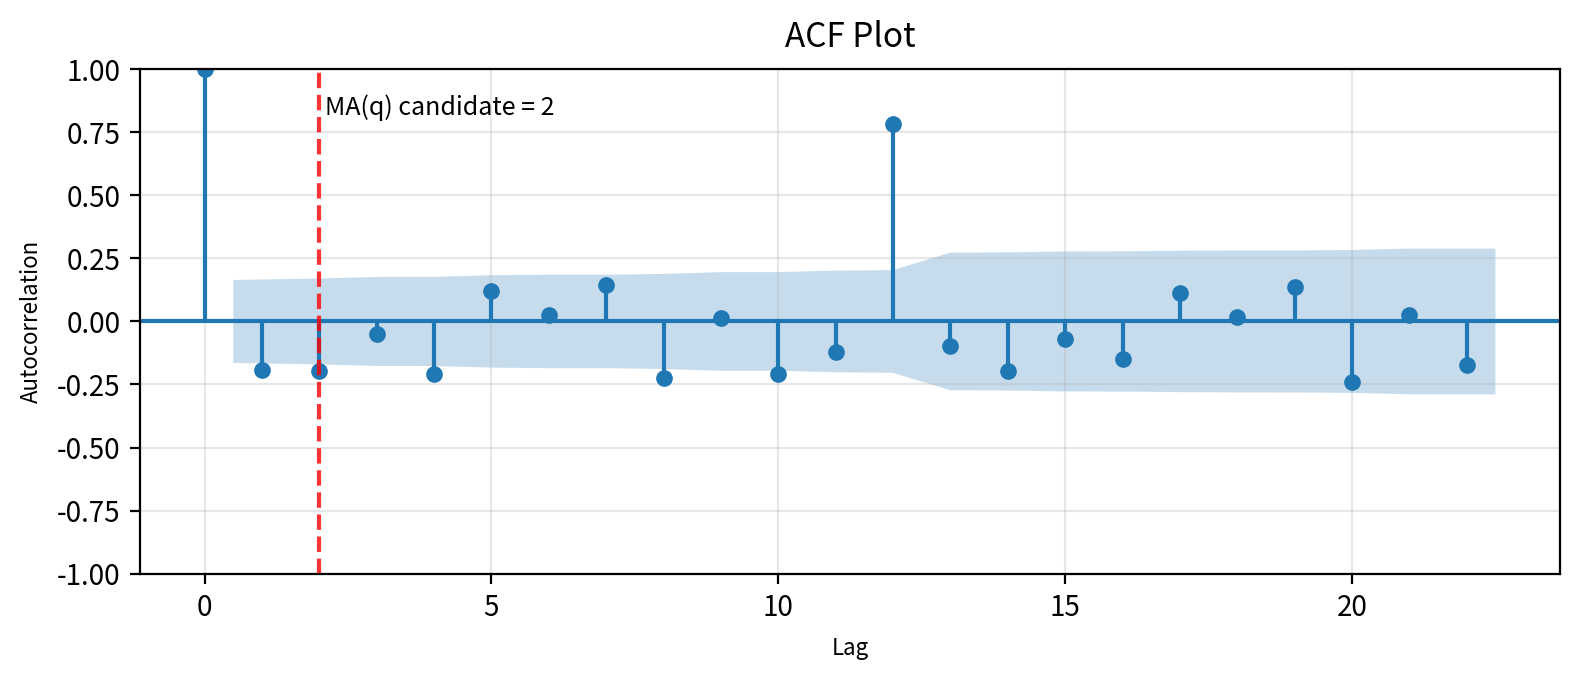

In [10]:
width_px = 1600
height_px = 700  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2-1) ACF Plot 그리기 -> ax 파라미터 필수
plot_acf(diff_df["Passengers"], ax=ax)

# 2-2) MA(q) 후보 시각화
ax.axvline(
    x=q_candidate,
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    color="red",
)

ax.text(
    q_candidate + 0.1,
    ax.get_ylim()[1] * 0.9,
    f"MA(q) candidate = {q_candidate}",
    fontsize=9,
    verticalalignment="top",
)

# 3) 그래프 꾸미기
ax.set_title("ACF Plot", fontsize=12, pad=8)
ax.set_xlabel("Lag", fontsize=8, labelpad=5)
ax.set_ylabel("Autocorrelation", fontsize=8, labelpad=5)
ax.grid(True, alpha=0.3)  # 배경 격자 표시

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [11]:
# 1) PACF 계산
pacf_vals = pacf(diff_df["Passengers"])
threshold = 2 / np.sqrt(len(diff_df["Passengers"]))

# 2) 결과표 생성
df_pacf = DataFrame(
    {
        "lag": np.arange(len(pacf_vals)),
        "pacf": pacf_vals,
    }
)

# 3) 유의성 판단
df_pacf["abs_pacf"] = df_pacf["pacf"].abs()
df_pacf["significant"] = df_pacf["abs_pacf"] > threshold

# 4) 보기 좋게 정리
df_pacf["pacf"] = df_pacf["pacf"].round(3)
df_pacf["abs_pacf"] = df_pacf["abs_pacf"].round(3)
df_pacf["threshold"] = round(threshold, 3)

# 5) lag=0 제외
df_pacf_result = df_pacf.query("lag > 0").reset_index(drop=True)

# 6) 연속 유의구간 계산
df_pacf_result["prev_significant"] = df_pacf_result["significant"].shift(1)

df_pacf_result["cut_candidate"] = (df_pacf_result["prev_significant"] == True) & (
    df_pacf_result["significant"] == False
)

df_pacf_result[["lag", "pacf", "significant", "cut_candidate"]]

,lag,pacf,significant,cut_candidate
0,1,-0.192,True,False
1,2,-0.245,True,False
2,3,-0.159,False,True
3,4,-0.355,True,False
4,5,-0.112,False,True
5,6,-0.169,True,False
6,7,0.078,False,True
7,8,-0.329,True,False
8,9,-0.075,False,True
9,10,-0.596,True,False


In [12]:
p_candidate = df_pacf_result.loc[df_pacf_result["cut_candidate"], "lag"].min() - 1
p_candidate

np.int64(2)

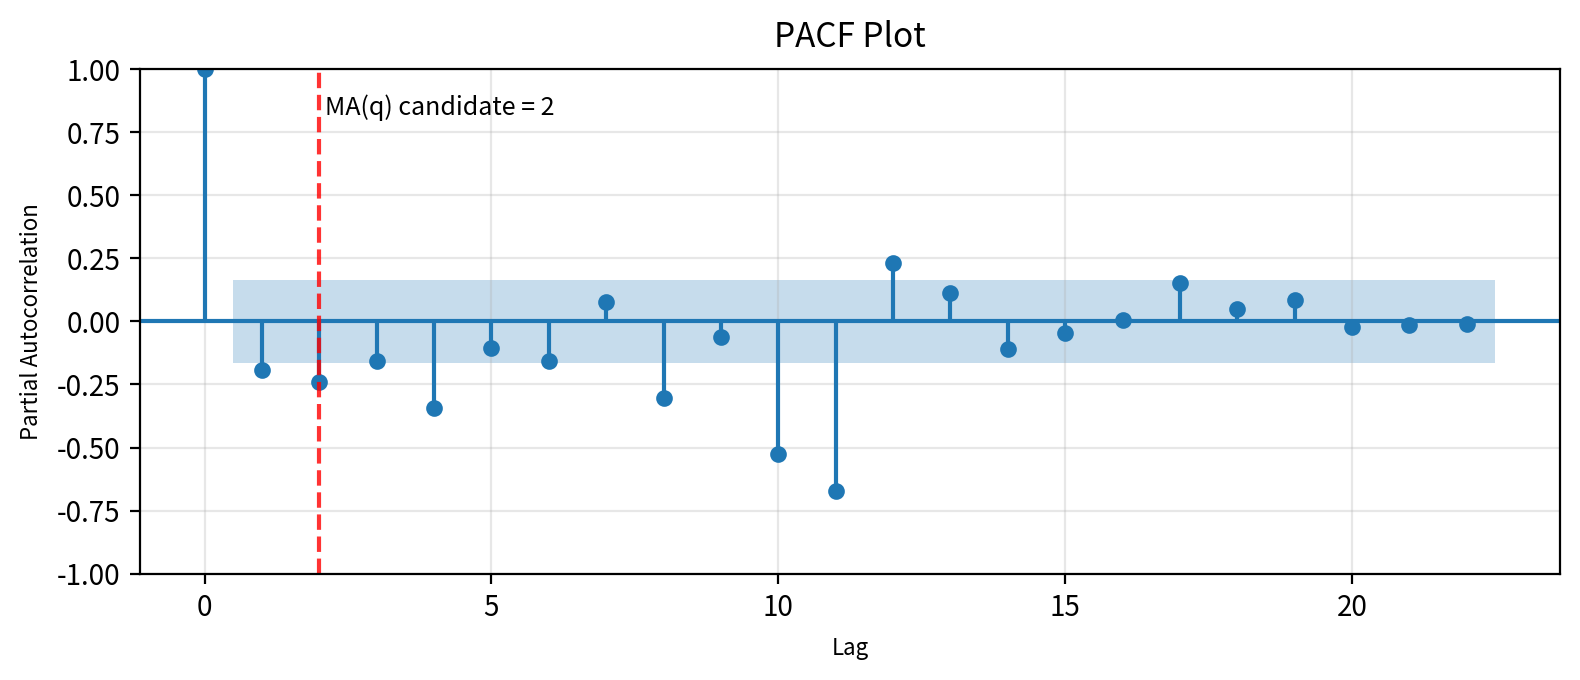

In [14]:
width_px = 1600
height_px = 700  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2-1) ACF Plot 그리기 -> ax 파라미터 필수
plot_pacf(diff_df["Passengers"], ax=ax)

# 2-2) MA(q) 후보 시각화
ax.axvline(
    x=p_candidate,
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    color="red",
)

ax.text(
    p_candidate + 0.1,
    ax.get_ylim()[1] * 0.9,
    f"MA(q) candidate = {p_candidate}",
    fontsize=9,
    verticalalignment="top",
)

# 3) 그래프 꾸미기
ax.set_title("PACF Plot", fontsize=12, pad=8)
ax.set_xlabel("Lag", fontsize=8, labelpad=5)
ax.set_ylabel("Partial Autocorrelation", fontsize=8, labelpad=5)
ax.grid(True, alpha=0.3)  # 배경 격자 표시

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [15]:
for i in range(0, p + 1):
    for j in range(0, q + 1):
        ARIMA(i, 2, j)

NameError: name 'p' is not defined

In [16]:
for d in [1, 2]:
    for i in range(0, p + 1):
        for j in range(0, q + 1):
            ARIMA(i, 2, j)

NameError: name 'p' is not defined